In [30]:
# Load the Port Data
import pandas as pd

# Load the ports data
ports_file_path = "D:\\AIS Project\\datasets\\datasets\\ports.csv"
ports_df = pd.read_csv(ports_file_path, sep='\t')  # Assuming the file is tab-separated

# Display the first few rows to verify
print(ports_df.head())

             name,port_id,lat,lon
0    VYSOTSKI,14928,60.616,28.566
1  UST-LUGA,8214872,59.683,28.434
2     LOKSA,81274125,59.5833,25.7
3         MUUGA,645,59.482,24.955
4    KUNDA,34679,59.5158,26.53313


In [31]:
# Split the single column into multiple columns
ports_df = ports_df['name,port_id,lat,lon'].str.split(',', expand=True)

# Rename the columns
ports_df.columns = ['name', 'port_id', 'lat', 'lon']

# Check the first few rows to confirm
print(ports_df.head())

       name   port_id      lat       lon
0  VYSOTSKI     14928   60.616    28.566
1  UST-LUGA   8214872   59.683    28.434
2     LOKSA  81274125  59.5833      25.7
3     MUUGA       645   59.482    24.955
4     KUNDA     34679  59.5158  26.53313


In [32]:
# Convert Data Types
# Convert latitude and longitude to numeric
ports_df['lat'] = pd.to_numeric(ports_df['lat'], errors='coerce')
ports_df['lon'] = pd.to_numeric(ports_df['lon'], errors='coerce')

# Check the data types
print(ports_df.dtypes)

name        object
port_id     object
lat        float64
lon        float64
dtype: object


In [33]:
# Handle Missing Data
# Drop rows with missing latitude or longitude values
ports_df.dropna(subset=['lat', 'lon'], inplace=True)

# Check the DataFrame after dropping missing values
print(ports_df.head())

       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313


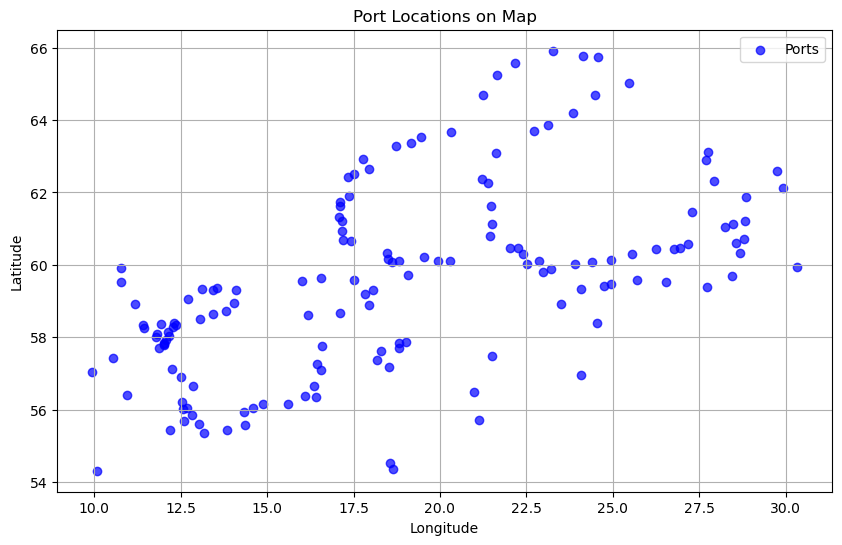

In [34]:
# Plot the Data
import matplotlib.pyplot as plt

# Create a scatter plot of ports
plt.figure(figsize=(10, 6))
plt.scatter(ports_df['lon'], ports_df['lat'], c='blue', marker='o', alpha=0.7, label='Ports')

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Port Locations on Map')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

In [35]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [36]:
import pandas as pd
import folium

In [37]:
# Step 1: Load the data
file_path = "D:\\AIS Project\\datasets\\datasets\\ports.csv"
ports_df = pd.read_csv(file_path)

# Step 2: Check the data
print("Original Data:")
print(ports_df.head())

# Step 3: Split the single column into multiple columns (if necessary)
# If the data is in a single column, split it into multiple columns
if len(ports_df.columns) == 1:
    ports_df = ports_df.iloc[:, 0].str.split(',', expand=True)
    ports_df.columns = ['name', 'port_id', 'lat', 'lon']

# Step 4: Convert latitude and longitude to numeric
ports_df['lat'] = pd.to_numeric(ports_df['lat'], errors='coerce')
ports_df['lon'] = pd.to_numeric(ports_df['lon'], errors='coerce')

# Step 5: Drop rows with missing latitude or longitude values
ports_df.dropna(subset=['lat', 'lon'], inplace=True)

# Step 6: Check the cleaned data
print("\nCleaned Data:")
print(ports_df.head())

# Step 7: Create a base map centered at the mean latitude and longitude
map_center = [ports_df['lat'].mean(), ports_df['lon'].mean()]
port_map = folium.Map(location=map_center, zoom_start=6)

Original Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313

Cleaned Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313


In [38]:
# Step 8: Add markers for each port
for index, row in ports_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],  # Latitude and longitude
        popup=f"Port: {row['name']} (ID: {row['port_id']})",  # Popup text
        icon=folium.Icon(color='blue', icon='anchor')  # Custom icon
    ).add_to(port_map)

In [39]:
# Step 9: Display the map with additional customization
port_map = folium.Map(
    location=[ports_df['lat'].mean(), ports_df['lon'].mean()],  # Center the map
    zoom_start=6,  # Initial zoom level
    tiles="OpenStreetMap"  # Map style (other options: "Stamen Terrain", "CartoDB positron")
)

# Add markers for each port
for index, row in ports_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],  # Latitude and longitude
        popup=f"Port: {row['name']} (ID: {row['port_id']})",  # Popup text
        icon=folium.Icon(color='blue', icon='anchor')  # Custom icon
    ).add_to(port_map)

# Display the map
port_map

In [42]:
# Step 9: Display the map with additional customization
port_map = folium.Map(
    location=[ports_df['lat'].mean(), ports_df['lon'].mean()],  # Center the map
    zoom_start=6,  # Initial zoom level
    tiles="OpenStreetMap"  # Map style (other options: "Stamen Terrain", "CartoDB positron")
)

# Add markers for each port
for index, row in ports_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],  # Latitude and longitude
        popup=f"Port: {row['name']} (ID: {row['port_id']})",  # Popup text
        icon=folium.Icon(color='blue', icon='anchor')  # Custom icon
    ).add_to(port_map)

# Save the map to an HTML file
output_file_path = "D:\\AIS Project\\datasets\\port_map.html"
port_map.save(output_file_path)

print(f"Map saved to: {output_file_path}")

Map saved to: D:\AIS Project\datasets\port_map.html


In [2]:
import pandas as pd
import folium

# Step 1: Load the data
file_path = "D:\\AIS Project\\datasets\\datasets\\ports.csv"
ports_df = pd.read_csv(file_path)

# Step 2: Check the original data
print("Original Data:")
print(ports_df.head())

# Step 3: Split the single column into multiple columns (if necessary)
if len(ports_df.columns) == 1:
    ports_df = ports_df.iloc[:, 0].str.split(',', expand=True)
    ports_df.columns = ['name', 'port_id', 'lat', 'lon']

# Step 4: Convert latitude and longitude to numeric
ports_df['lat'] = pd.to_numeric(ports_df['lat'], errors='coerce')
ports_df['lon'] = pd.to_numeric(ports_df['lon'], errors='coerce')

# Step 5: Drop rows with missing latitude or longitude values
ports_df.dropna(subset=['lat', 'lon'], inplace=True)

# Step 6: Check the cleaned data
print("\nCleaned Data:")
print(ports_df.head())

# Step 7: Create a base map centered at the mean latitude and longitude
map_center = [ports_df['lat'].mean(), ports_df['lon'].mean()]
port_map = folium.Map(
    location=map_center,
    zoom_start=6,
    tiles="OpenStreetMap"
)

# Step 8: Add circles for each port (5 nautical miles radius)
# 1 nautical mile = 1.852 kilometers
radius_km = 5 * 1.852  # Convert 5 nautical miles to kilometers
radius_m = radius_km * 1000  # Convert kilometers to meters for folium

for index, row in ports_df.iterrows():
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=radius_m,  # Radius in meters
        popup=f"Port: {row['name']} (ID: {row['port_id']})",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.2
    ).add_to(port_map)

# Step 9: Display the map
port_map

Original Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313

Cleaned Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313


In [8]:
import pandas as pd
import folium

# Step 1: Load the data
file_path = "D:\\AIS Project\\datasets\\datasets\\ports.csv"
ports_df = pd.read_csv(file_path)

# Step 2: Check the original data
print("Original Data:")
print(ports_df.head())

# Step 3: Split the single column into multiple columns (if necessary)
if len(ports_df.columns) == 1:
    ports_df = ports_df.iloc[:, 0].str.split(',', expand=True)
    ports_df.columns = ['name', 'port_id', 'lat', 'lon']

# Step 4: Convert latitude and longitude to numeric
ports_df['lat'] = pd.to_numeric(ports_df['lat'], errors='coerce')
ports_df['lon'] = pd.to_numeric(ports_df['lon'], errors='coerce')

# Step 5: Drop rows with missing latitude or longitude values
ports_df.dropna(subset=['lat', 'lon'], inplace=True)

# Step 6: Check the cleaned data
print("\nCleaned Data:")
print(ports_df.head())

# Step 7: Create a base map with additional customization
port_map = folium.Map(
    location=[ports_df['lat'].mean(), ports_df['lon'].mean()],  # Center the map
    zoom_start=6,  # Initial zoom level
    tiles="CartoDB positron",  # Map style
    attr="CartoDB",  # Attribution
    control_scale=True,  # Add scale bar
    min_zoom=2,  # Minimum zoom level
    max_zoom=18,  # Maximum zoom level
    width='100%',  # Map width (can use pixels like '800' or percentage)
    height='100%'  # Map height (can use pixels like '600' or percentage)
)

# Step 8: Add circles for each port (5 nautical miles radius) with customization
radius_km = 5 * 1.852  # Convert 5 nautical miles to kilometers
radius_m = radius_km * 1000  # Convert kilometers to meters for folium

for index, row in ports_df.iterrows():
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=radius_m,  # Radius in meters
        popup=folium.Popup(f"Port: {row['name']} (ID: {row['port_id']})", max_width=300),  # Enhanced popup
        color='blue',  # Circle outline color
        weight=2,  # Outline thickness
        opacity=0.8,  # Outline opacity
        fill=True,
        fill_color='blue',
        fill_opacity=0.3,  # Increased visibility of overlapping areas
        tooltip=row['name']  # Hover text
    ).add_to(port_map)

# Step 9: Add additional map features
folium.LatLngPopup().add_to(port_map)  # Click to show coordinates
folium.LayerControl().add_to(port_map)  # Layer control toggle

# Step 10: Save the map to an HTML file
output_file_path = "D:\\AIS Project\\datasets\\port_map_circle.html"
port_map.save(output_file_path)
print(f"Map saved to: {output_file_path}")

# Step 11: Display the map in notebook (if using Jupyter)
port_map

Original Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313

Cleaned Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313
Map saved to: D:\AIS Project\datasets\port_map_circle.html


In [4]:
import pandas as pd
import folium

# Step 1: Load the data
file_path = "D:\\AIS Project\\datasets\\datasets\\ports.csv"
ports_df = pd.read_csv(file_path)

# Step 2: Check the original data
print("Original Data:")
print(ports_df.head())

# Step 3: Split the single column into multiple columns (if necessary)
if len(ports_df.columns) == 1:
    ports_df = ports_df.iloc[:, 0].str.split(',', expand=True)
    ports_df.columns = ['name', 'port_id', 'lat', 'lon']

# Step 4: Convert latitude and longitude to numeric
ports_df['lat'] = pd.to_numeric(ports_df['lat'], errors='coerce')
ports_df['lon'] = pd.to_numeric(ports_df['lon'], errors='coerce')

# Step 5: Drop rows with missing latitude or longitude values
ports_df.dropna(subset=['lat', 'lon'], inplace=True)

# Step 6: Check the cleaned data
print("\nCleaned Data:")
print(ports_df.head())

# Step 7: Create a base map centered at the mean latitude and longitude
map_center = [ports_df['lat'].mean(), ports_df['lon'].mean()]
port_map = folium.Map(
    location=map_center,
    zoom_start=6,
    tiles="https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors'
)

# Step 8: Add circles for each port (5 nautical miles radius)
radius_km = 5 * 1.852  # Convert 5 nautical miles to kilometers
radius_m = radius_km * 1000  # Convert kilometers to meters for folium

for index, row in ports_df.iterrows():
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=radius_m,  # Radius in meters
        popup=f"Port: {row['name']} (ID: {row['port_id']})",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.2
    ).add_to(port_map)

# Step 9: Add layer control (optional)
folium.LayerControl().add_to(port_map)

# Step 10: Display the map
port_map

Original Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313

Cleaned Data:
       name   port_id      lat       lon
0  VYSOTSKI     14928  60.6160  28.56600
1  UST-LUGA   8214872  59.6830  28.43400
2     LOKSA  81274125  59.5833  25.70000
3     MUUGA       645  59.4820  24.95500
4     KUNDA     34679  59.5158  26.53313
